# Loan Default Prediction

## Phase 4: SHAP Explainability

### Objective

The objective of this notebook is to explain the model's predictions using SHAP
(SHapley Additive exPlanations) — both globally (which features matter most overall)
and individually (why the model made a specific prediction for one applicant).

In this notebook, we will:
- Load the cleaned dataset and the saved Logistic Regression model
- Generate a SHAP summary plot (global feature importance)
- Generate a SHAP waterfall plot explaining one individual prediction

In [6]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
df = pd.read_csv('../data/cleaned_train.csv')

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Convert True/False columns to 1/0 (SHAP needs plain numbers)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = joblib.load('../models/logistic_regression_model.pkl')
print("Model loaded successfully")

Model loaded successfully


### Global Feature Importance

This plot shows which features matter most across all applicants, and whether
high or low values of each feature push predictions toward approval or rejection.

Background dataset has 491 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=491 when initializing the masker.


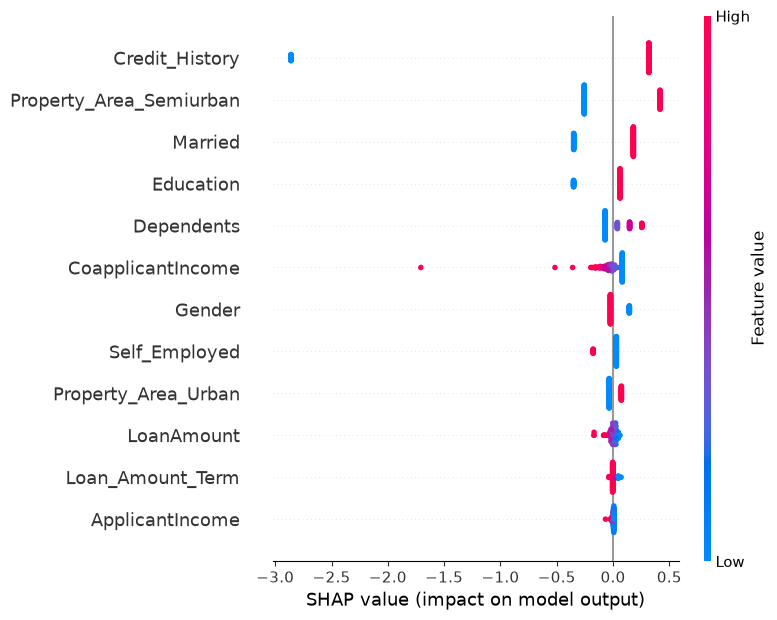

In [3]:
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

### Individual Prediction Explanation

This plot explains why the model made its prediction for one specific applicant,
breaking down which features pushed the prediction toward approval vs rejection.

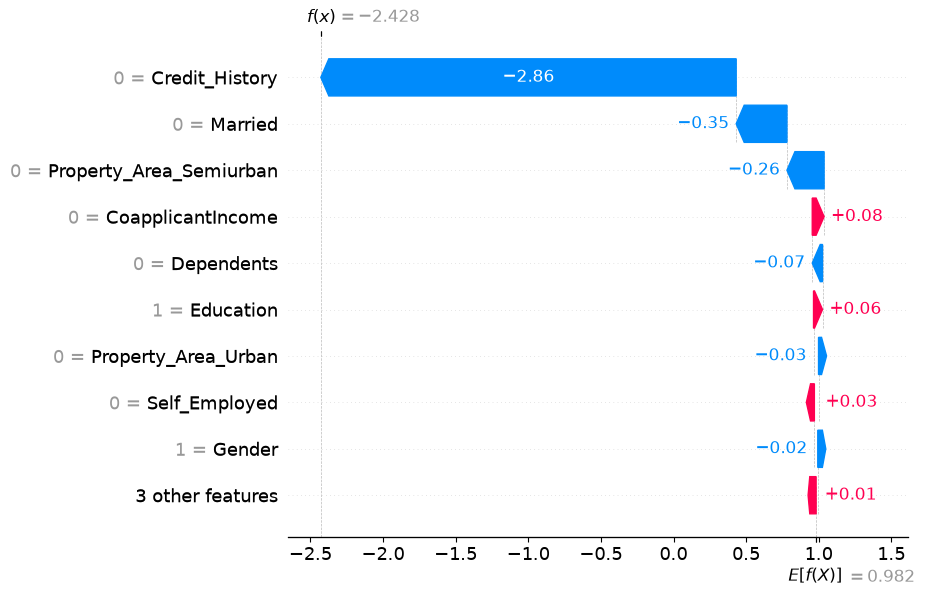

Actual outcome: Rejected
Model's predicted probability of approval: 0.08


In [4]:
# Explain the first applicant in the test set
shap.plots.waterfall(shap_values[0])

applicant = X_test.iloc[0]
actual = y_test.iloc[0]
pred_prob = model.predict_proba(X_test.iloc[[0]])[0][1]

print("Actual outcome:", "Approved" if actual == 1 else "Rejected")
print(f"Model's predicted probability of approval: {pred_prob:.2f}")